<a href="https://colab.research.google.com/github/eileen795/MSSP-6070/blob/main/Assignments/assignment1/assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 200)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/MSSP607/Assignments/assignment1/data_academic_performance.xlsx'
df = pd.read_excel(
    file_path,
    sheet_name="SABER11_SABERPRO"
)

df.head()
df.columns

Mounted at /content/drive


Index(['COD_S11', 'GENDER', 'EDU_FATHER', 'EDU_MOTHER', 'OCC_FATHER', 'OCC_MOTHER', 'STRATUM', 'SISBEN', 'PEOPLE_HOUSE', 'Unnamed: 9', 'INTERNET', 'TV', 'COMPUTER', 'WASHING_MCH', 'MIC_OVEN', 'CAR',
       'DVD', 'FRESH', 'PHONE', 'MOBILE', 'REVENUE', 'JOB', 'SCHOOL_NAME', 'SCHOOL_NAT', 'SCHOOL_TYPE', 'MAT_S11', 'CR_S11', 'CC_S11', 'BIO_S11', 'ENG_S11', 'Cod_SPro', 'UNIVERSITY',
       'ACADEMIC_PROGRAM', 'QR_PRO', 'CR_PRO', 'CC_PRO', 'ENG_PRO', 'WC_PRO', 'FEP_PRO', 'G_SC', 'PERCENTILE', '2ND_DECILE', 'QUARTILE', 'SEL', 'SEL_IHE'],
      dtype='object')

## 2.Data cleaning

In [ ]:
quality_summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "missing_pct": df.isna().mean().mul(100).round(2),
    "unique_values": df.nunique()
})
display(quality_summary)

,dtype,missing,missing_pct,unique_values
COD_S11,object,0,0.0,12411
GENDER,object,0,0.0,2
EDU_FATHER,object,0,0.0,12
EDU_MOTHER,object,0,0.0,12
OCC_FATHER,object,0,0.0,12
OCC_MOTHER,object,0,0.0,12
STRATUM,object,0,0.0,7
SISBEN,object,0,0.0,6
PEOPLE_HOUSE,object,0,0.0,13
Unnamed: 9,float64,12411,100.0,0


In [ ]:
pro_scores = ['CR_PRO', 'QR_PRO', 'CC_PRO', 'WC_PRO', 'ENG_PRO', 'FEP_PRO']

df['PRO_mean'] = df[pro_scores].mean(axis=1)

# Define a custom order for education levels
education_order = [
    'Ninguno', '0', 'Incomplete primary', 'Complete primary', 'Incomplete Secundary',
    'Complete Secundary', 'Incomplete technical or technological',
    'Complete technique or technology', 'Incomplete Professional Education',
    'Complete professional education', 'Postgraduate education', 'Not sure'
]

# Convert education columns to ordered categorical type
df['EDU_MOTHER'] = pd.Categorical(df['EDU_MOTHER'], categories=education_order, ordered=True)
df['EDU_FATHER'] = pd.Categorical(df['EDU_FATHER'], categories=education_order, ordered=True)

df[['G_SC', 'PRO_mean']].head(20)
df[['G_SC', 'PRO_mean']].corr()

,G_SC,PRO_mean
G_SC,1.000000,0.926759
PRO_mean,0.926759,1.000000


The clear definition of global score is not provide by the database.After calculation, Global Score is not calculated as the average of the six PRO assessment scores, it is highly correlated with the average PRO score (r = 0.927). Therefore, we use the average of the six PRO scores as an alternative overall performance measure, as it captures a very similar pattern of student performance.

## 3.Numerical descriptive **statistics**

In [ ]:
numeric_cols = ['MAT_S11', 'CR_S11', 'CC_S11', 'BIO_S11', 'ENG_S11','QR_PRO', 'CR_PRO', 'CC_PRO', 'ENG_PRO', 'WC_PRO', 'FEP_PRO', 'G_SC','SEL', 'SEL_IHE']

basic_summary = df[numeric_cols].describe().T
basic_summary

def descriptive_profile(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    return pd.Series({
        "count": series.count(),
        "mean": series.mean(),
        "median": series.median(),
        "mode": series.mode().iloc[0],
        "min": series.min(),
        "max": series.max(),
        "range": series.max() - series.min(),
        "variance": series.var(),
        "std_dev": series.std(),
        "Q1": q1,
        "Q3": q3,
        "IQR": q3 - q1,
        "skewness": series.skew()
    })

profile = df[numeric_cols].apply(descriptive_profile).T
profile.round(2)

,count,mean,median,mode,min,max,range,variance,std_dev,Q1,Q3,IQR,skewness
MAT_S11,12411.0,64.32,64.0,64.0,26.0,100.0,74.0,140.98,11.87,56.0,72.0,16.0,0.40
CR_S11,12411.0,60.78,61.0,64.0,24.0,100.0,76.0,100.52,10.03,54.0,67.0,13.0,0.21
CC_S11,12411.0,60.71,60.0,62.0,0.0,100.0,100.0,102.43,10.12,54.0,67.0,13.0,0.35
BIO_S11,12411.0,63.95,64.0,61.0,11.0,100.0,89.0,124.48,11.16,56.0,71.0,15.0,0.30
ENG_S11,12411.0,61.80,59.0,52.0,26.0,100.0,74.0,204.43,14.30,50.0,72.0,22.0,0.61
QR_PRO,12411.0,77.42,85.0,100.0,1.0,100.0,99.0,514.09,22.67,65.0,96.0,31.0,-1.18
CR_PRO,12411.0,62.20,67.0,95.0,1.0,100.0,99.0,765.44,27.67,42.0,86.0,44.0,-0.52
CC_PRO,12411.0,59.19,65.0,92.0,1.0,100.0,99.0,840.53,28.99,36.0,85.0,49.0,-0.42
ENG_PRO,12411.0,67.50,74.0,96.0,1.0,100.0,99.0,650.00,25.50,51.0,88.0,37.0,-0.80
WC_PRO,12411.0,53.70,56.0,0.0,0.0,100.0,100.0,900.10,30.00,28.0,80.0,52.0,-0.18


## 4.Visualize score distributions

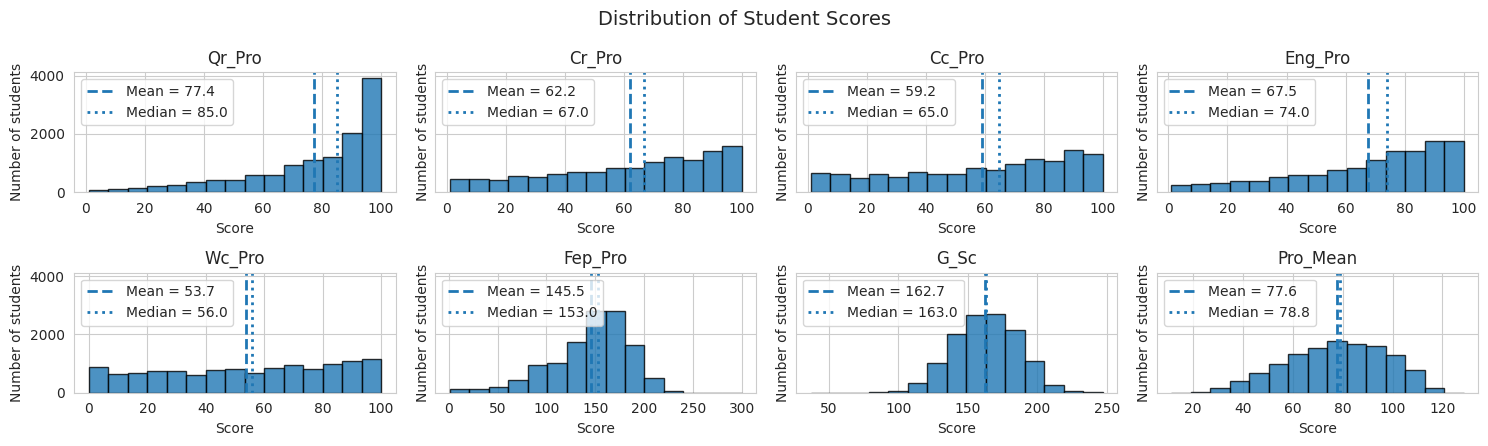

In [ ]:
score_columns = ['QR_PRO', 'CR_PRO', 'CC_PRO', 'ENG_PRO', 'WC_PRO', 'FEP_PRO', 'G_SC','PRO_mean' ]
fig, axes = plt.subplots(2, 4, figsize=(15, 4.5), sharey=True)
axes = axes.flatten()

for ax, col in zip(axes, score_columns):
    ax.hist(df[col], bins=15, edgecolor="black", alpha=0.8)
    ax.axvline(df[col].mean(), linestyle="--", linewidth=2, label=f"Mean = {df[col].mean():.1f}")
    ax.axvline(df[col].median(), linestyle=":", linewidth=2, label=f"Median = {df[col].median():.1f}")
    ax.set_title(col.title())
    ax.set_xlabel("Score")
    ax.set_ylabel("Number of students")
    ax.legend()

fig.suptitle("Distribution of Student Scores", fontsize=14)
plt.tight_layout()
plt.show()

## 5.Outliers and robust statistics

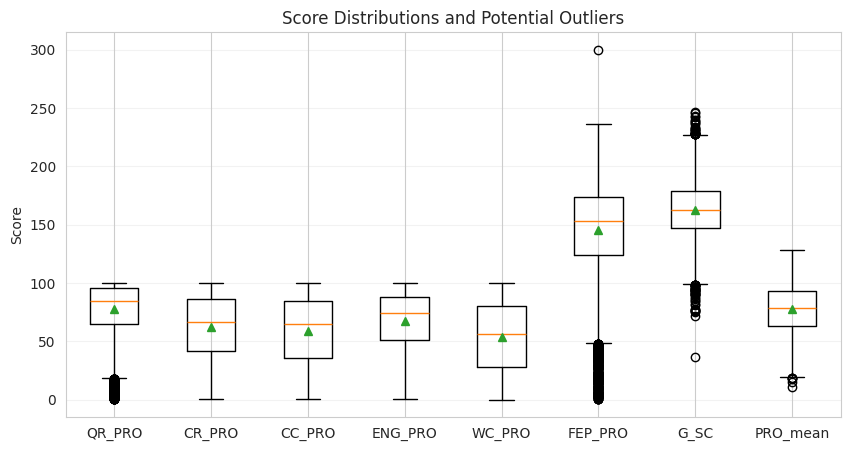

In [ ]:
plt.figure(figsize=(10, 5))
plt.boxplot(
    [df[c] for c in score_columns],
    tick_labels=score_columns,
    showmeans=True
)
plt.ylabel("Score")
plt.title("Score Distributions and Potential Outliers")
plt.grid(axis="y", alpha=0.25)
plt.show()

In [ ]:
outlier_rows = []
for col in score_columns:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_rows.append([col, q1, q3, lower, upper, count])

outlier_summary = pd.DataFrame(
    outlier_rows,
    columns=["variable", "Q1", "Q3", "lower_fence", "upper_fence", "flagged_count"]
)
outlier_summary.round(2)

,variable,Q1,Q3,lower_fence,upper_fence,flagged_count
0,QR_PRO,65.0,96.0,18.50,142.50,290
1,CR_PRO,42.0,86.0,-24.00,152.00,0
2,CC_PRO,36.0,85.0,-37.50,158.50,0
3,ENG_PRO,51.0,88.0,-4.50,143.50,0
4,WC_PRO,28.0,80.0,-50.00,158.00,0
5,FEP_PRO,124.0,174.0,49.00,249.00,308
6,G_SC,147.0,179.0,99.00,227.00,67
7,PRO_mean,63.5,93.0,19.25,137.25,6


note: WC_PRE contains 309 observations with a value of 0. Since the dataset does not provide a clear definition of this value, we cannot determine whether 0 represents an actual score, a missed test, or a missing value. Therefore, we will not remove these observations without further evidence.

## 6.Categorical descriptive statistics

In [ ]:
categorical_cols = [
   'GENDER', 'EDU_FATHER', 'EDU_MOTHER', 'OCC_FATHER', 'OCC_MOTHER', 'STRATUM', 'SISBEN', 'PEOPLE_HOUSE', 'INTERNET', 'TV', 'COMPUTER', 'WASHING_MCH', 'MIC_OVEN', 'CAR',
       'DVD', 'FRESH', 'PHONE', 'MOBILE', 'REVENUE', 'JOB', 'SCHOOL_NAME', 'SCHOOL_NAT', 'SCHOOL_TYPE','UNIVERSITY',
       'ACADEMIC_PROGRAM']

for col in categorical_cols:
    table = pd.DataFrame({
        "count": df[col].value_counts(),
        "percent": df[col].value_counts(normalize=True).mul(100).round(1)
    })
    print(f"\n{col.upper()}")
    display(table)


GENDER


,count,percent
GENDER,,
M,7368,59.4
F,5043,40.6



EDU_FATHER


,count,percent
EDU_FATHER,,
Complete professional education,3016,28.8
Complete Secundary,2843,27.2
Complete technique or technology,1194,11.4
Incomplete Secundary,1091,10.4
Postgraduate education,1085,10.4
Incomplete Professional Education,425,4.1
Not sure,407,3.9
Incomplete technical or technological,277,2.6
Ninguno,123,1.2



EDU_MOTHER


...

,count,percent
SCHOOL_TYPE,,
ACADEMIC,7834,63.1
TECHNICAL/ACADEMIC,3513,28.3
TECHNICAL,1059,8.5
Not apply,5,0.0



UNIVERSITY


,count,percent
UNIVERSITY,,
UNIVERSIDAD DE LOS ANDES-BOGOTÁ D.C.,696,5.6
UNIVERSIDAD INDUSTRIAL DE SANTANDER-BUCARAMANGA,397,3.2
"ESCUELA COLOMBIANA DE INGENIERIA""JULIO GARAVITO""-BOGOTÁ D.C.",397,3.2
UNIVERSIDAD DEL NORTE-BARRANQUILLA,376,3.0
"UNIVERSIDAD DISTRITAL""FRANCISCO JOSE DE CALDAS""-BOGOTÁ D.C.",335,2.7
...,...,...
INSTITUCION UNIVERSITARIA DE ENVIGADO-ENVIGADO,3,0.0
ESCUELA DE INGENIEROS MILITARES-BOGOTÁ D.C.,2,0.0
CORPORACION UNIFICADA NACIONAL DE EDUCACION SUPERIOR-CUN-BOGOTÁ D.C.,2,0.0



ACADEMIC_PROGRAM


,count,percent
ACADEMIC_PROGRAM,,
INDUSTRIAL ENGINEERING,5318,42.8
CIVIL ENGINEERING,3320,26.8
MECHANICAL ENGINEERING,1135,9.1
CHEMICAL ENGINEERING,1000,8.1
ELECTRONIC ENGINEERING,849,6.8
ELECTRIC ENGINEERING,278,2.2
MECHATRONICS ENGINEERING,82,0.7
CATASTRAL ENGINEERING AND GEODESY,78,0.6
PRODUCTION ENGINEERING,60,0.5


# 1）Does parental education influence outcomes, and if so, how much?

mother education

In [ ]:
mother_summary = (
    df.groupby('EDU_MOTHER', observed=True)['PRO_mean']
      .agg(['count', 'mean', 'median', 'std'])
      .round(2)
      .dropna()
)

print("Impact of Mother's Education Level on PRO_mean:")
display(mother_summary)

Impact of Mother's Education Level on PRO_mean:


,count,mean,median,std
EDU_MOTHER,,,,
Ninguno,34,69.04,74.08,22.14
Incomplete Secundary,1056,71.95,72.83,19.04
Complete Secundary,3106,74.12,74.83,19.22
Incomplete technical or technological,341,77.19,79.17,18.03
Complete technique or technology,1495,78.30,79.50,19.00
Incomplete Professional Education,502,80.71,81.75,18.34
Complete professional education,3059,82.45,84.33,19.45
Postgraduate education,997,87.69,91.67,18.39
Not sure,179,74.07,74.00,21.64


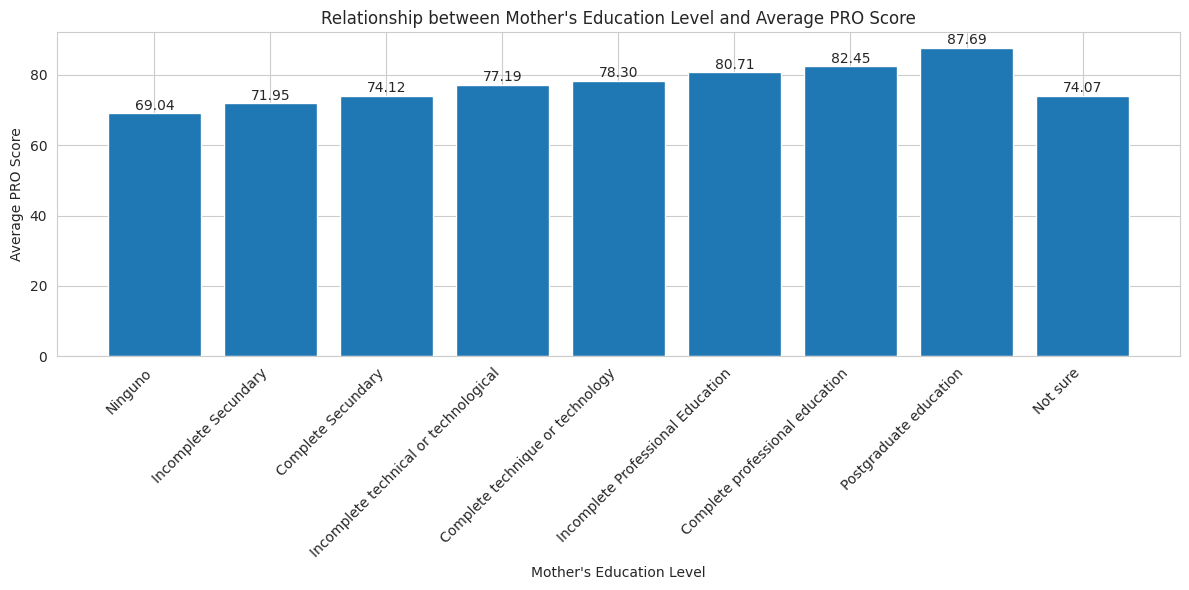

In [ ]:
plt.figure(figsize=(12, 6))

plt.bar(
    range(len(mother_summary)),
    mother_summary['mean']
)

plt.xticks(
    range(len(mother_summary)),
    mother_summary.index,
    rotation=45,
    ha='right'
)

plt.title("Relationship between Mother's Education Level and Average PRO Score")
plt.xlabel("Mother's Education Level")
plt.ylabel("Average PRO Score")

for i, value in enumerate(mother_summary['mean']):
    plt.text(
        i,
        value + 1,
        f"{value:.2f}",
        ha='center'
    )

plt.tight_layout()
plt.show()

father education

In [ ]:
father_summary = (
    df.groupby('EDU_FATHER', observed=True)['PRO_mean']
      .agg(['count', 'mean', 'median', 'std'])
      .dropna()
      .round(2)
)

print("Impact of Father's Education Level on PRO_mean:")
display(father_summary)

Impact of Father's Education Level on PRO_mean:


,count,mean,median,std
EDU_FATHER,,,,
Ninguno,123,74.41,75.50,20.08
Incomplete Secundary,1091,72.45,73.00,19.35
Complete Secundary,2843,74.31,75.33,19.60
Incomplete technical or technological,277,77.19,77.33,18.57
Complete technique or technology,1194,78.87,80.58,18.65
Incomplete Professional Education,425,81.21,82.00,18.59
Complete professional education,3016,81.70,84.00,19.36
Postgraduate education,1085,88.81,92.50,17.68
Not sure,407,75.63,75.67,19.47


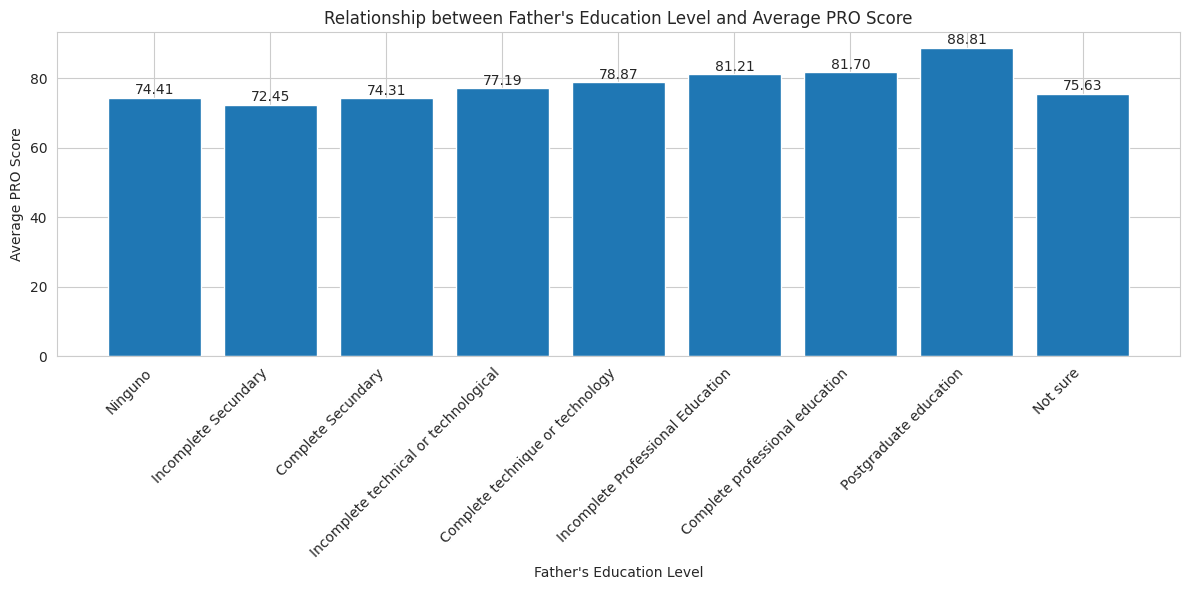

In [ ]:
plt.figure(figsize=(12, 6))

plt.bar(
    range(len(father_summary)),
    father_summary['mean']
)

plt.xticks(
    range(len(father_summary)),
    father_summary.index,
    rotation=45,
    ha='right'
)

plt.title("Relationship between Father's Education Level and Average PRO Score")
plt.xlabel("Father's Education Level")
plt.ylabel("Average PRO Score")

for i, value in enumerate(father_summary['mean']):
    plt.text(
        i,
        value + 1,
        f"{value:.2f}",
        ha='center'
    )

plt.tight_layout()
plt.show()

note: ninguno means none in Spanish, then what's the difference between ninguno and 0

Overall, parental education is associated with substantial differences in students' PRO scores. The difference between the lowest and highest mother's education groups is 18.65 points, while the corresponding difference for father's education is 16.36 points. Both figures suggest that students with more highly educated parents tend to have higher average PRO scores. However, these descriptive comparisons show an association rather than a causal effect.

# 2)Which groups/stratum performs best? Are there differences between groups/stratums? Explain your analysis.

In [ ]:
stratum_summary = (
    df[df['STRATUM'] != 0]
      .groupby('STRATUM', observed=True)['PRO_mean']
      .agg(['count', 'mean', 'median', 'std'])
      .dropna()
      .round(2)
)

display(stratum_summary)

,count,mean,median,std
STRATUM,,,,
Stratum 1,1709,69.70,69.83,19.77
Stratum 2,4029,74.00,74.67,19.22
Stratum 3,4045,78.04,79.17,18.73
Stratum 4,1578,85.53,88.50,17.96
Stratum 5,633,89.79,93.17,16.96
Stratum 6,403,92.23,97.33,17.34


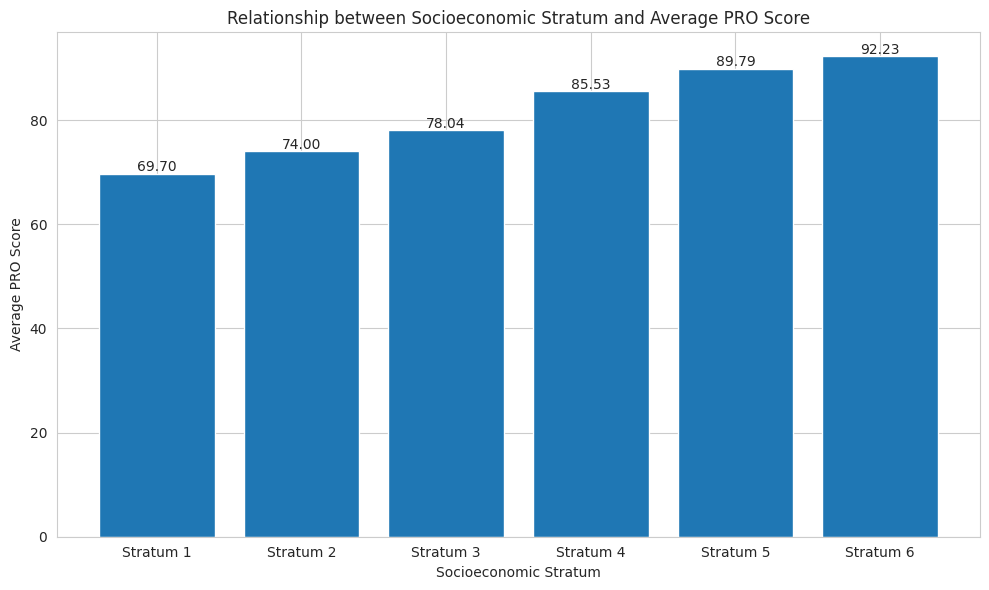

In [ ]:
plt.figure(figsize=(10, 6))

plt.bar(
    range(len(stratum_summary)),
    stratum_summary['mean']
)

plt.xticks(
    range(len(stratum_summary)),
    stratum_summary.index
)

plt.title("Relationship between Socioeconomic Stratum and Average PRO Score")
plt.xlabel("Socioeconomic Stratum")
plt.ylabel("Average PRO Score")

# Add mean score above each bar
for i, value in enumerate(stratum_summary['mean']):
    plt.text(
        i,
        value + 0.5,
        f"{value:.2f}",
        ha='center'
    )

plt.tight_layout()
plt.show()

Average PRO scores increase steadily across socioeconomic strata, from 69.70 in Stratum 1 to 92.23 in Stratum 6. Stratum 6 has the highest average performance, while Stratum 1 has the lowest, with a 22.53-point gap between them. This pattern indicates a clear positive association between socioeconomic stratum and academic performance, although it does not establish a causal relationship.

# 3）How does each gender perform in the global assessment?

In [ ]:
# Summary statistics by gender
gender_summary = (
    df.groupby('GENDER', observed=True)['PRO_mean']
      .agg(['count', 'mean', 'median', 'std'])
      .dropna()
      .round(2)
)

print("PRO Score by Gender:")
display(gender_summary)

PRO Score by Gender:


,count,mean,median,std
GENDER,,,,
F,5043,76.71,77.83,19.50
M,7368,78.18,79.50,19.87


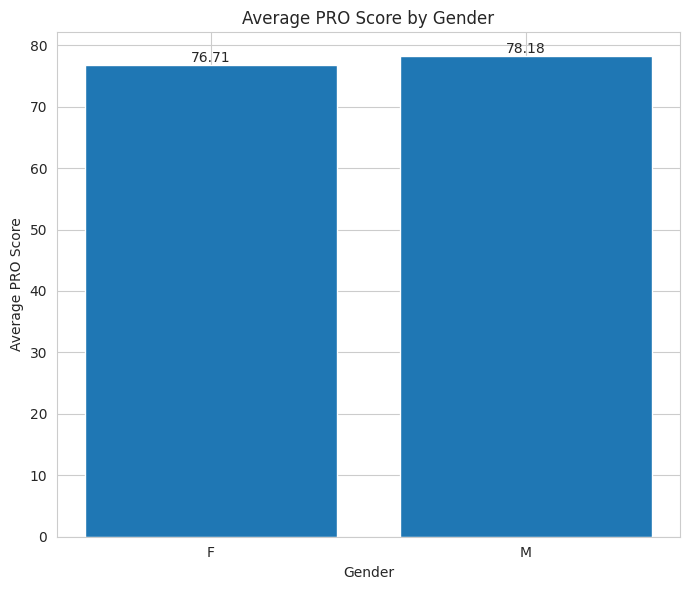

In [ ]:
plt.figure(figsize=(7, 6))

plt.bar(
    range(len(gender_summary)),
    gender_summary['mean']
)

plt.xticks(
    range(len(gender_summary)),
    gender_summary.index
)

plt.title("Average PRO Score by Gender")
plt.xlabel("Gender")
plt.ylabel("Average PRO Score")

# Add mean score above each bar
for i, value in enumerate(gender_summary['mean']):
    plt.text(
        i,
        value + 0.5,
        f"{value:.2f}",
        ha='center'
    )

plt.tight_layout()
plt.show()

Male students have a slightly higher average PRO score than female students. The average score for male students is 78.18, compared with 76.71 for female students, resulting in a difference of only 1.47 points. This suggests that overall academic performance is relatively similar across genders, although male students show a slightly higher average score in this dataset.